## Model 4 — PCA-Enhanced Salary Model with Hyperparameter Tuning

### Overview
This model builds on the earlier salary-prediction experiments by addressing a key limitation of the raw skill features:  
although 27 skill indicators were included in the dataset (basic/intermediate/advanced across several domains), their **individual predictive power was weak**, and their relationships were highly correlated and partially redundant. To capture the *combined* structure of the skill profile while reducing noise, we applied **Principal Component Analysis (PCA)** to the 27 skill variables.

PCA was first run on the full job dataset, and the number of components was chosen using the cumulative explained variance profile.  
The first **10 principal components** captured roughly **70% of the variance**, and therefore were retained. These components reflect latent “competency axes” (e.g., programming intensity, analytics–ML continuum, cloud vs. data-pipelines orientation), which serve as compact numerical summaries of the skill configuration.

The trained PCA model was saved to disk and integrated into a reusable transformation function so it can be applied later to both job records and individual user skill profiles.

### Model Inputs
After adding the 10 PCA components to the dataset, the model used the following features:

- Company-related: `size_code`, `sector_code`, `state_code`, `ownership_code`
- Role-related: `seniority_code`, `title_rich_code`
- Skill structure: `skill_PC1` … `skill_PC10`

All categorical variables were encoded using XGBoost’s native categorical support.

The target variable remained the estimated mean salary (`sal_mean`).

### Hyperparameter Tuning
To prevent underfitting/overfitting and find the most stable tree configuration, we performed a **Grid Search** over several key XGBoost hyperparameters:

- **n_estimators**: 100–700  
- **max_depth**: 2–6  
- **learning_rate**: 0.025–0.2  

A 3-fold cross-validated grid search (`GridSearchCV`) identified the best combination based on validation R².

**Best parameters identified:**

- `n_estimators = 100`  
- `max_depth = 2`  
- `learning_rate = 0.05`  

This configuration produced the most stable model with minimal overfitting.

### Performance
Using the tuned parameters, the final model achieved:

- **R² (test)**: ~0.30  
- **R² (train)**: ~0.35  
- **RMSE**: ~31,500  
- **MAE**: ~25,000  

These metrics are realistically aligned with the structural limits of the dataset.  
Salary is inherently high-variance, and the target itself is an **estimated salary**, not a ground-truth compensation figure—this imposes a natural cap on attainable accuracy.

### Interpretation
The feature importance profile shows:

- **Job title** and **location** remain the strongest determinants of salary.  
- **Sector** and **company size** contribute moderately.  
- **Skill PCA components** provide secondary but meaningful predictive power.  
- **Seniority** remains weak due to sparse extraction in the dataset.

Overall, PCA improved model stability, reduced noise, and made skill features more interpretable, but the dataset’s structural limitations continue to constrain maximum accuracy.

### Conclusion
Model 4 represents the most complete and robust salary predictor developed in this chapter.  
It integrates:
- structured categorical signals,
- dimensionality-reduced skill profiles,
- and tuned XGBoost parameters.

The model is sufficiently strong for downstream components of the project, including:
- user positioning in the job market,
- salary-aligned upskilling recommendations,
- and benchmarking across roles and regions.

Further accuracy gains would require fundamentally richer data (true salaries, robust seniority extraction, years of experience), not additional modeling tweaks.


## Set up
* Libraries
* Path
* Dataset

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_PCA_DF

In [5]:
df_ch0 = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)
df_ch0.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,skill_PC1,skill_PC2,skill_PC3,skill_PC4,skill_PC5,skill_PC6,skill_PC7,skill_PC8,skill_PC9,skill_PC10
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,0.462016,0.107793,-0.286497,-0.961280,0.050588,-0.055616,0.395975,0.480314,0.016349,-0.239943
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0.018662,-0.339362,0.631396,-0.972227,-0.139904,-0.183168,0.286340,0.235295,0.125379,0.213347
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,-0.485473,-0.143990,0.604327,0.428753,0.363498,-0.395078,0.811758,0.003043,0.025900,-0.188561
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0.009683,1.123316,0.112544,-0.535952,-0.301241,-0.235044,0.295499,-0.211524,0.196350,-0.283105
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,-0.502115,-0.138427,0.758690,-0.065791,-0.458638,-0.280799,-0.722739,-0.690126,0.256452,-0.619181


## Prepare the data

In [6]:
print(", ".join([f"'{c}'" for c in df_ch0.columns]))

'Job Description', 'Rating', 'Size', 'Founded', 'Industry', 'Sector', 'role_source', 'state', 'ownership_clean', 'job_description_clean', 'job_title_base', 'seniority_combined', 'job_title_norm', 'job_title_family', 'domain', 'sal_is_hourly', 'sal_min', 'sal_max', 'sal_mean', 'title_plus_description', 'core_programming__basic', 'core_programming__intermediate', 'core_programming__advanced', 'data_engineering_pipelines__basic', 'data_engineering_pipelines__intermediate', 'data_engineering_pipelines__advanced', 'ml_ai__basic', 'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic', 'analytics_stats__intermediate', 'analytics_stats__advanced', 'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced', 'cloud__basic', 'cloud__intermediate', 'cloud__advanced', 'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced', 'productivity_workflow__basic', 'productivity_workflow__intermediate', 'productivity_workflow__advanced', 'soft_skills__core', 'soft_skills__leader

In [7]:
response = df_ch0['sal_mean'].copy()
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code', 
            # Skills
            'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
            'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
            ]].copy() 

In [22]:
cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')


In [23]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   size_code                                 6161 non-null   category
 1   sector_code                               6161 non-null   category
 2   state_code                                6161 non-null   category
 3   ownership_code                            6161 non-null   category
 4   seniority_code                            6161 non-null   category
 5   title_rich_code                           6161 non-null   category
 6   core_programming__basic                   6161 non-null   int64   
 7   core_programming__intermediate            6161 non-null   int64   
 8   core_programming__advanced                6161 non-null   int64   
 9   data_engineering_pipelines__basic         6161 non-null   int64   
 10  data_engineering_pipelin

## Salary model v4

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=101
)

param_grid = {
    "n_estimators": [100,200, 300, 400, 500, 600, 700],
    "max_depth":    [2, 3, 4, 5, 6],
    "learning_rate": [0.125, 0.025,0.05, 0.1, 0.2],
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Test for model capacity
pred_train = best_model.predict(X_train)


print("Best params:", grid.best_params_)
print("R2:", r2_score(y_test, y_pred))
print("R2 train:", r2_score(y_train, pred_train))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


Fitting 3 folds for each of 175 candidates, totalling 525 fits
Best params: {'learning_rate': 0.025, 'max_depth': 3, 'n_estimators': 200}
R2: 0.3046140702076433
R2 train: 0.3785999865849109
RMSE: 31510.451242133047
MAE: 24877.04713478305


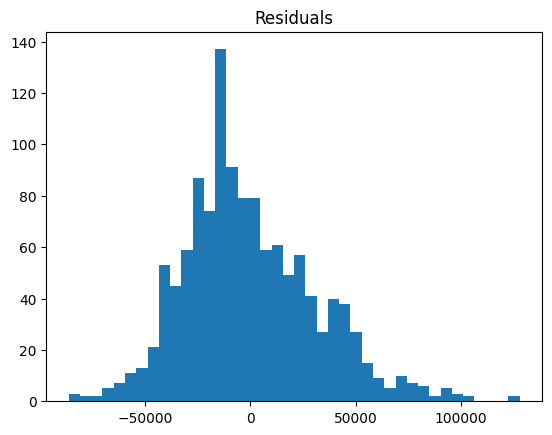

In [17]:
res = y_test - y_pred
plt.hist(res, bins=40)
plt.title('Residuals')
plt.show()

Text(0.5, 1.0, 'Predicted vs Actual Salary')

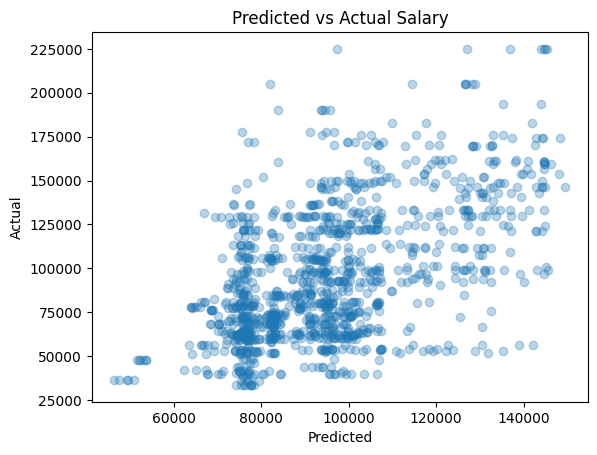

In [18]:
plt.scatter(y_pred, y_test, alpha=0.3)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actual Salary")

In [19]:
var_importance = pd.DataFrame({'features' : features.columns, 'importance' : best_model.feature_importances_})

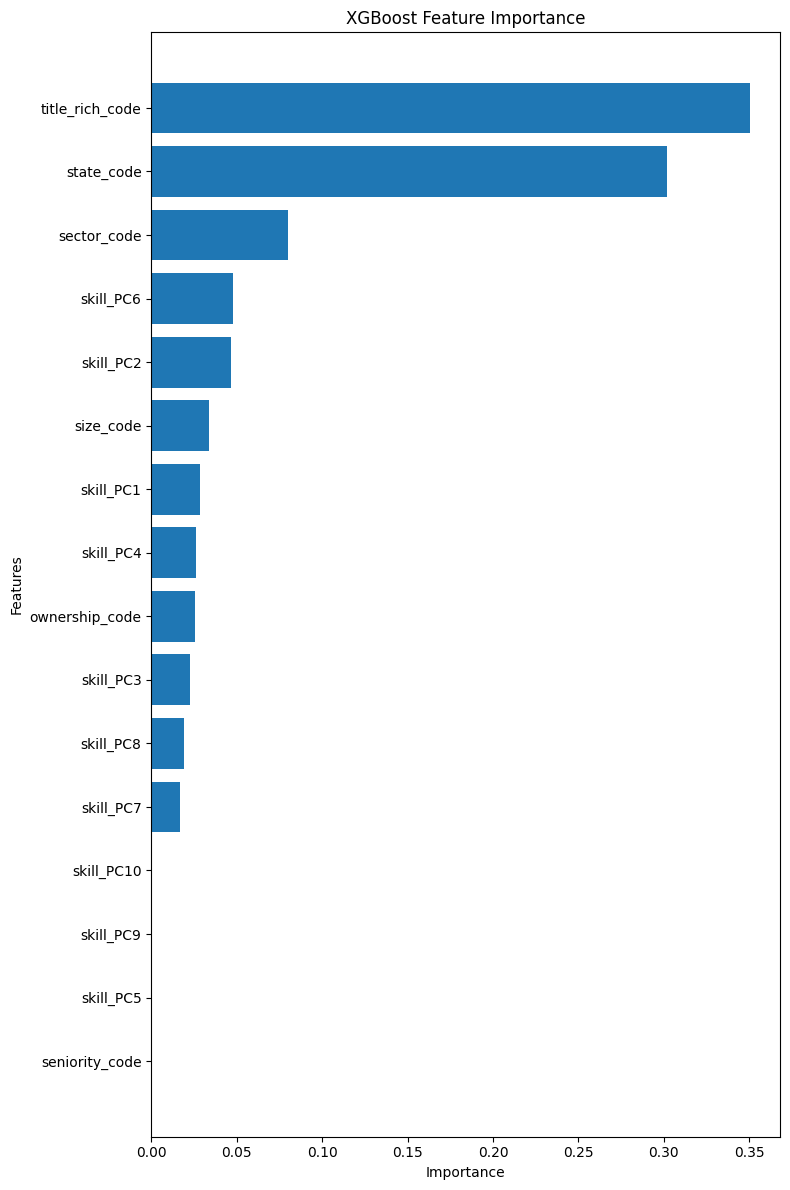

In [20]:
importance_df = var_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 12))
plt.barh(importance_df['features'], importance_df['importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.tight_layout()


## Save model

In [26]:
import joblib
from src.job_intel.config import MODELS_DIR

joblib.dump(best_model, MODELS_DIR / "salary_model_v4.pkl")


['/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/models/salary_model_v4.pkl']